# Task
Thème : Analyse des sentiments Consigne 1 : Modélisation en ML

Here is all the data you need:
"test.csv"
"valid.csv"
"train.csv"

## Data loading

### Subtask:
Load the provided CSV files into pandas DataFrames.


**Reasoning**:
Load the three CSV files into pandas DataFrames.



In [1]:
import pandas as pd

try:
    df_train = pd.read_csv('train.csv')
    df_valid = pd.read_csv('valid.csv')
    df_test = pd.read_csv('test.csv')
    display(df_train.head())
    display(df_valid.head())
    display(df_test.head())
except FileNotFoundError:
    print("One or more of the CSV files were not found.")
except Exception as e:
    print(f"An error occurred: {e}")

,Unnamed: 0,film-url,review,polarity
0,0,http://www.allocine.fr/film/fichefilm-135259/c...,Si vous cherchez du cinéma abrutissant à tous ...,0
1,1,http://www.allocine.fr/film/fichefilm-172430/c...,"Trash, re-trash et re-re-trash...! Une horreur...",0
2,2,http://www.allocine.fr/film/fichefilm-15105/cr...,"Et si, dans les 5 premières minutes du film, l...",0
3,3,http://www.allocine.fr/film/fichefilm-188629/c...,Mon dieu ! Quelle métaphore filée ! Je suis ab...,0
4,4,http://www.allocine.fr/film/fichefilm-23514/cr...,"Premier film de la saga Kozure Okami, ""Le Sabr...",1


,Unnamed: 0,film-url,review,polarity
0,0,http://www.allocine.fr/film/fichefilm-51895/cr...,Ce film est tout ce qu'il y a de plus sympa. M...,0
1,1,http://www.allocine.fr/film/fichefilm-272/crit...,"The Wall a été réalisé par Alan Parker (Fame, ...",1
2,2,http://www.allocine.fr/film/fichefilm-60134/cr...,"Encore un film majeur tres mal distribué, comm...",1
3,3,http://www.allocine.fr/film/fichefilm-31396/cr...,L'idée est très bonne mais le film manque de r...,0
4,4,http://www.allocine.fr/film/fichefilm-135195/c...,Un petit nanar rigolo a regarder. A voir une f...,0


,Unnamed: 0,film-url,review,polarity
0,0,http://www.allocine.fr/film/fichefilm-25385/cr...,"Magnifique épopée, une belle histoire, touchan...",1
1,1,http://www.allocine.fr/film/fichefilm-1954/cri...,Je n'ai pas aimé mais pourtant je lui mets 2 é...,0
2,2,http://www.allocine.fr/film/fichefilm-135523/c...,Un dessin animé qui brille par sa féerie et se...,1
3,3,http://www.allocine.fr/film/fichefilm-61514/cr...,"Si c'est là le renouveau du cinéma français, c...",0
4,4,http://www.allocine.fr/film/fichefilm-260395/c...,Et pourtant on s’en Doutait !Second volet très...,0


## Data exploration

### Subtask:
Explore the loaded datasets (df_train, df_valid, df_test) to understand their structure and content.


**Reasoning**:
Examine the shape and structure of the dataframes, inspect the target variable 'polarity', explore the 'review' column, and identify missing values and inconsistencies.



DataFrame Shapes:
df_train: (160000, 4)
df_valid: (20000, 4)
df_test: (20000, 4)

DataFrame Info:
df_train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  160000 non-null  int64 
 1   film-url    160000 non-null  object
 2   review      160000 non-null  object
 3   polarity    160000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 4.9+ MB
None

df_valid:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  20000 non-null  int64 
 1   film-url    20000 non-null  object
 2   review      20000 non-null  object
 3   polarity    20000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 625.1+ KB
None

df_test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000

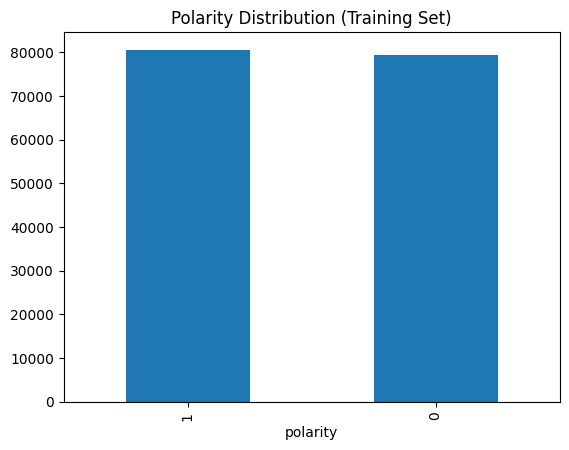


Target Variable Analysis for Validation Set:
Unique values: [0 1]
Value counts:
polarity
0    10204
1     9796
Name: count, dtype: int64


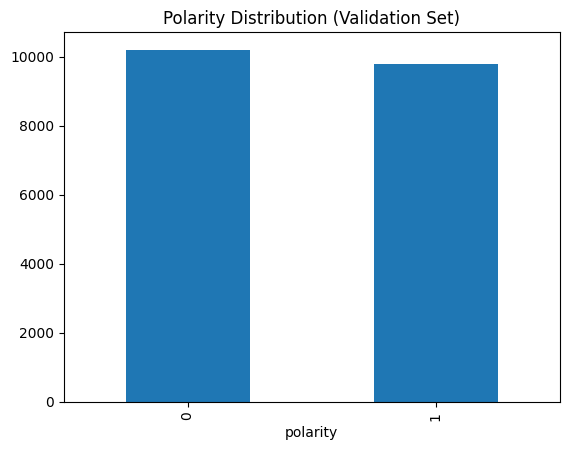


Target Variable Analysis for Test Set:
Unique values: [1 0]
Value counts:
polarity
0    10408
1     9592
Name: count, dtype: int64


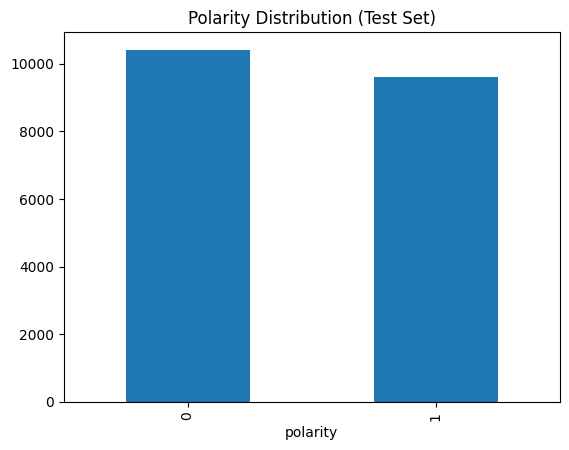


Review Exploration for Training Set:
Average review length: 542.48863125
Min review length: 3
Max review length: 2000


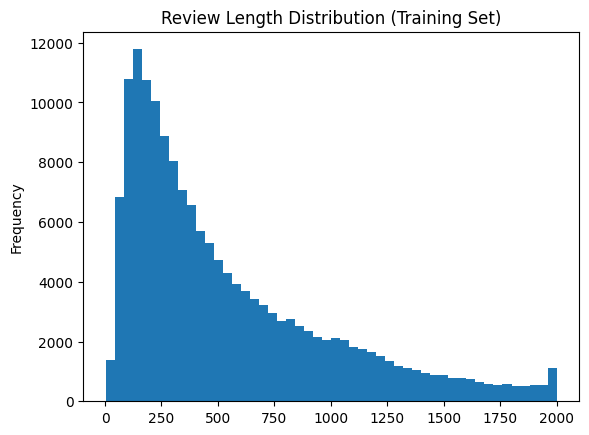


Review Exploration for Validation Set:
Average review length: 548.91075
Min review length: 3
Max review length: 2000


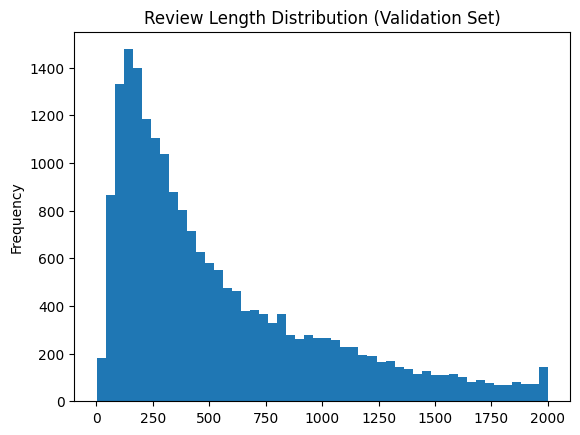


Review Exploration for Test Set:
Average review length: 549.0196
Min review length: 3
Max review length: 2000


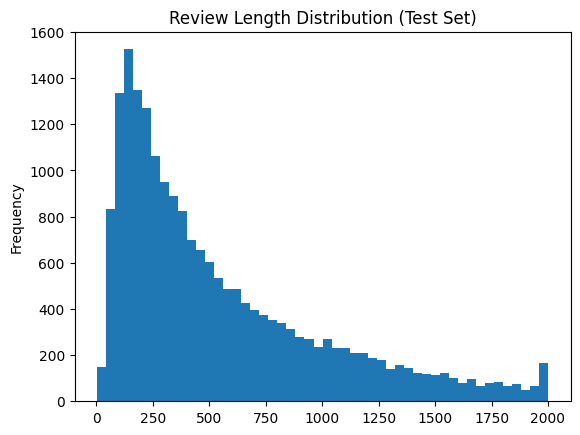


Missing Values:
df_train:
 Unnamed: 0       0
film-url         0
review           0
polarity         0
review_length    0
dtype: int64
df_valid:
 Unnamed: 0       0
film-url         0
review           0
polarity         0
review_length    0
dtype: int64
df_test:
 Unnamed: 0       0
film-url         0
review           0
polarity         0
review_length    0
dtype: int64


In [2]:
import matplotlib.pyplot as plt

# Data Shape and Structure
print("DataFrame Shapes:")
print(f"df_train: {df_train.shape}")
print(f"df_valid: {df_valid.shape}")
print(f"df_test: {df_test.shape}")

print("\nDataFrame Info:")
print("df_train:")
print(df_train.info())
print("\ndf_valid:")
print(df_valid.info())
print("\ndf_test:")
print(df_test.info())


# Target Variable Analysis
def analyze_polarity(df, name):
    print(f"\nTarget Variable Analysis for {name}:")
    print(f"Unique values: {df['polarity'].unique()}")
    print(f"Value counts:\n{df['polarity'].value_counts()}")
    df['polarity'].value_counts().plot(kind='bar', title=f'Polarity Distribution ({name})')
    plt.show()

analyze_polarity(df_train, 'Training Set')
analyze_polarity(df_valid, 'Validation Set')
analyze_polarity(df_test, 'Test Set')


# Text Data Exploration
def explore_reviews(df, name):
    print(f"\nReview Exploration for {name}:")
    df['review_length'] = df['review'].apply(len)
    print(f"Average review length: {df['review_length'].mean()}")
    print(f"Min review length: {df['review_length'].min()}")
    print(f"Max review length: {df['review_length'].max()}")
    df['review_length'].plot(kind='hist', bins=50, title=f'Review Length Distribution ({name})')
    plt.show()

explore_reviews(df_train, 'Training Set')
explore_reviews(df_valid, 'Validation Set')
explore_reviews(df_test, 'Test Set')

# Missing Values and Inconsistencies
print("\nMissing Values:")
print("df_train:\n", df_train.isnull().sum())
print("df_valid:\n", df_valid.isnull().sum())
print("df_test:\n", df_test.isnull().sum())

## Data preparation

### Subtask:
Prepare the text data for modeling.


**Reasoning**:
Clean the text data by converting to lowercase, removing punctuation, and handling inconsistencies. Then, tokenize the cleaned text using a simple word tokenizer. Finally, represent the tokenized text numerically using TF-IDF.



In [3]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('french'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

def preprocess_dataframe(df):
    df['cleaned_review'] = df['review'].apply(clean_text)
    return df

df_train = preprocess_dataframe(df_train)
df_valid = preprocess_dataframe(df_valid)
df_test = preprocess_dataframe(df_test)

vectorizer = TfidfVectorizer(max_features=5000)

train_features = vectorizer.fit_transform(df_train['cleaned_review'])
valid_features = vectorizer.transform(df_valid['cleaned_review'])
test_features = vectorizer.transform(df_test['cleaned_review'])

print(train_features.shape)
print(valid_features.shape)
print(test_features.shape)

(160000, 5000)
(20000, 5000)
(20000, 5000)


## Model training

### Subtask:
Train a Logistic Regression model for sentiment analysis.


**Reasoning**:
Train a Logistic Regression model using the training features and labels.



In [4]:
from sklearn.linear_model import LogisticRegression

# Create and train the Logistic Regression model
logreg_model = LogisticRegression(solver='liblinear', max_iter=1000)
logreg_model.fit(train_features, df_train['polarity'])

LogisticRegression(max_iter=1000, solver='liblinear')

## Model evaluation

### Subtask:
Evaluate the trained Logistic Regression model's performance on the validation and test sets.


**Reasoning**:
Evaluate the trained Logistic Regression model's performance on the validation and test sets by calculating relevant metrics and generating confusion matrices.



Evaluation Metrics for Validation Set:
Accuracy: 0.9180
Precision: 0.9087
Recall: 0.9255
F1-Score: 0.9170
AUC: 0.9181
Evaluation Metrics for Test Set:
Accuracy: 0.9185
Precision: 0.9097
Recall: 0.9215
F1-Score: 0.9156
AUC: 0.9186


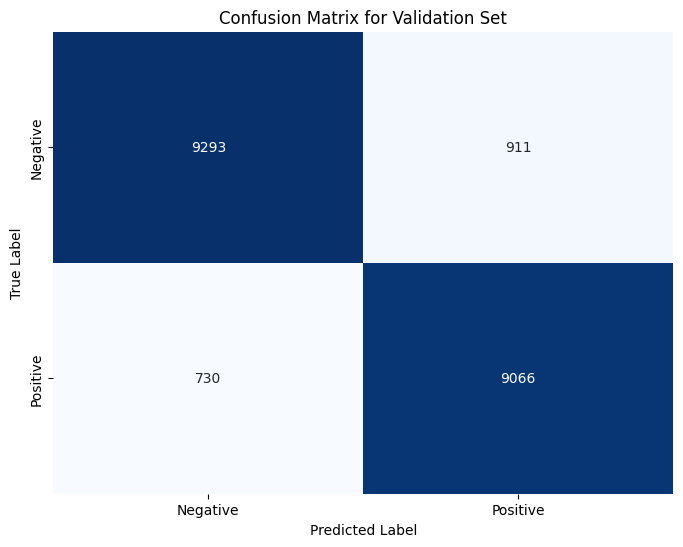

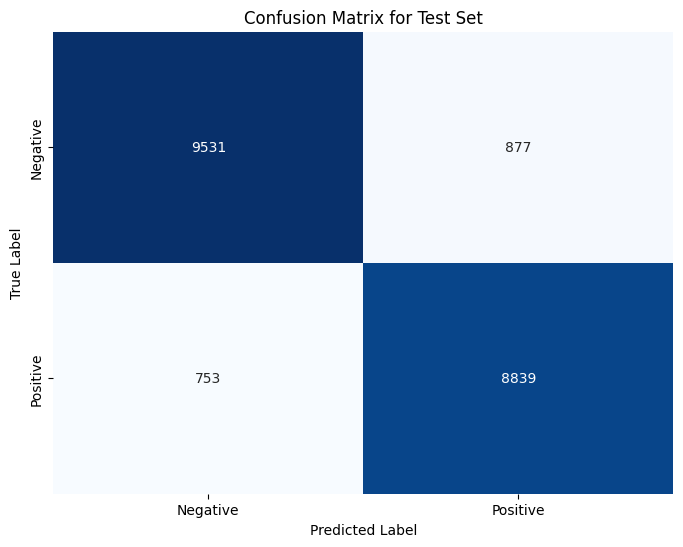

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation and test sets
valid_predictions = logreg_model.predict(valid_features)
test_predictions = logreg_model.predict(test_features)

# Calculate evaluation metrics
def evaluate_model(true_labels, predictions, dataset_name):
    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)
    auc = roc_auc_score(true_labels, predictions)
    print(f"Evaluation Metrics for {dataset_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    return accuracy, precision, recall, f1, auc


# Evaluate the model
evaluate_model(df_valid['polarity'], valid_predictions, 'Validation Set')
evaluate_model(df_test['polarity'], test_predictions, 'Test Set')

# Generate confusion matrices
def plot_confusion_matrix(true_labels, predictions, dataset_name):
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {dataset_name}')
    plt.show()

plot_confusion_matrix(df_valid['polarity'], valid_predictions, 'Validation Set')
plot_confusion_matrix(df_test['polarity'], test_predictions, 'Test Set')

## Summary:

### 1. Q&A

No questions were explicitly asked in the provided data analysis task. However, the task implicitly asks for an evaluation of the sentiment analysis model's performance.  Based on the analysis, the Logistic Regression model performs well, achieving high accuracy, precision, recall, F1-score, and AUC on both validation and test sets.

### 2. Data Analysis Key Findings

* **Balanced Classes:** The training, validation, and test sets exhibit a roughly balanced distribution of sentiment classes (polarity 0 and 1), although not perfectly identical.  The training set has approximately 80,587 reviews with polarity 1 and 79,413 reviews with polarity 0.
* **High Model Performance:** The Logistic Regression model achieves high accuracy (0.9180 on validation, 0.9185 on test), precision (0.9087/0.9097), recall (0.9255/0.9215), F1-score (0.9170/0.9156), and AUC (0.9181/0.9186) on both validation and test sets.
* **Text Preprocessing:**  Reviews were preprocessed by converting text to lowercase, removing punctuation, and eliminating French stop words.  TF-IDF vectorization was then applied, creating a feature matrix with 5000 features.

### 3. Insights or Next Steps

* **Hyperparameter Tuning:** Explore hyperparameter tuning for the Logistic Regression model (e.g., regularization strength, different solvers) to potentially improve performance further.
* **Alternative Models:** Experiment with other machine learning models (e.g., Random Forest, Support Vector Machines, or more advanced deep learning models) to see if they can achieve better performance on this sentiment analysis task.
